In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

In [26]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [51]:
print("Statistical Analysis of the Dataset:\n")
df.describe().T

Statistical Analysis of the Dataset:



,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [28]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Zero value counts (treated as missing):\n")
for col in zero_cols:
    print(f"{col}: {(df[col] == 0).sum()}")

Zero value counts (treated as missing):

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [29]:
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("Zero values after cleaning:")
for col in zero_cols:
    print(f"{col}: {(df[col] == 0).sum()}")

Zero values after cleaning:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


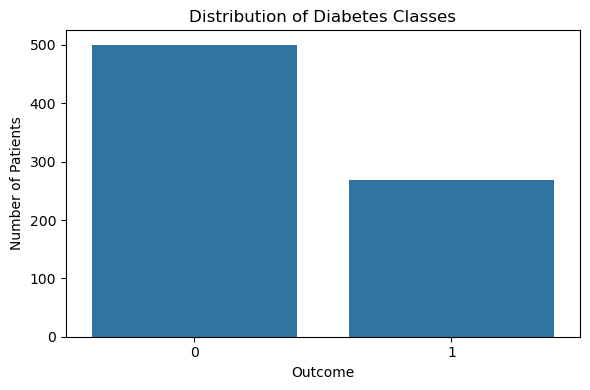

In [ ]:
#Dataset Class Distribution Plot
#Figure X. Distribution of Diabetes Classes in the Dataset
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)

plt.title('Distribution of Diabetes Classes')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

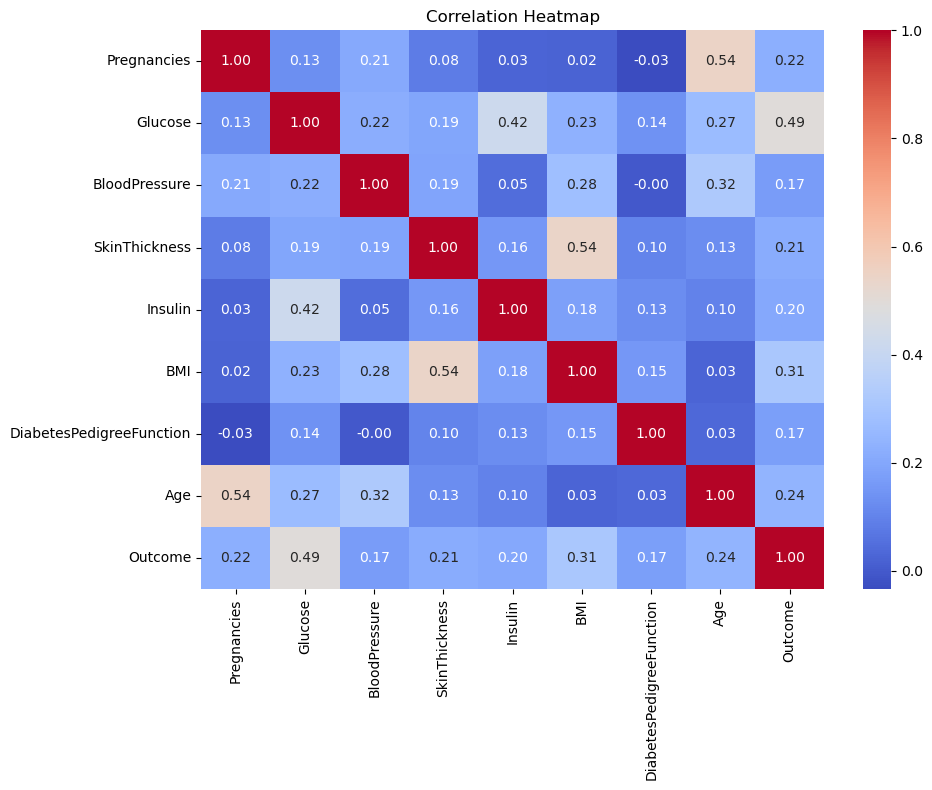

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [31]:
print("Correlation of each feature with Outcome:\n")
corr_with_target = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print(corr_with_target)

Correlation of each feature with Outcome:

Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [32]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 614 samples
Testing set: 154 samples


In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, lr_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results:
Accuracy:  0.7532
Precision: 0.6667
Recall:    0.6182
F1-Score:  0.6415

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [35]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Results:")
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall:    {recall_score(y_test, dt_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, dt_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Results:
Accuracy:  0.7273
Precision: 0.5915
Recall:    0.7636
F1-Score:  0.6667

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        99
           1       0.59      0.76      0.67        55

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.73       154



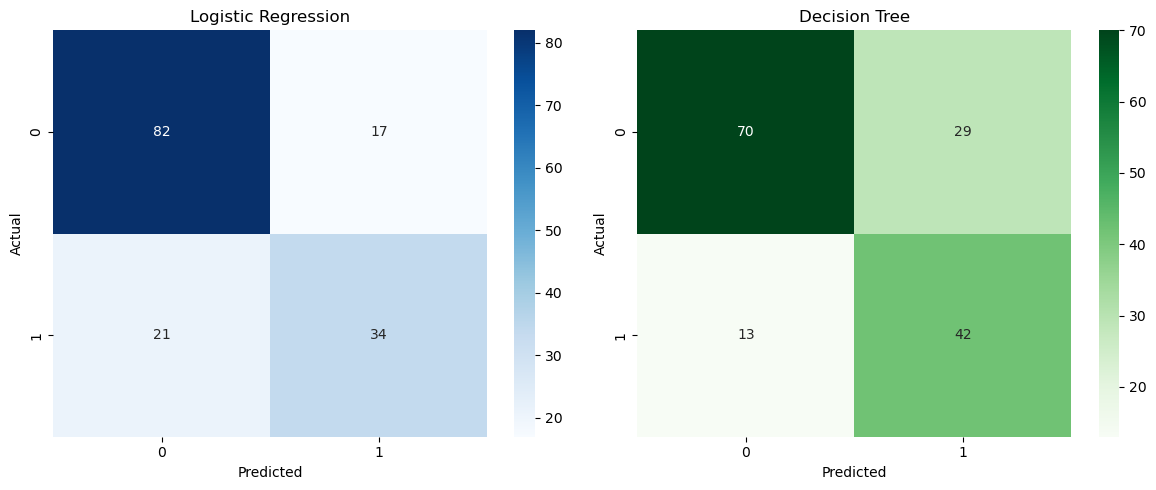

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

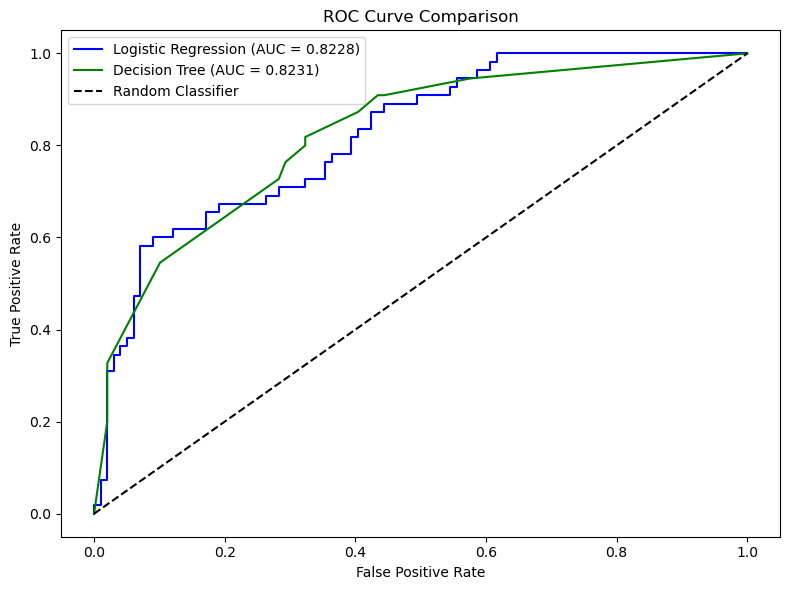

In [37]:
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
dt_prob = dt_model.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', color='blue')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

In [38]:
lr_cv = cross_val_score(LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
                        scaler.fit_transform(X), y, cv=10, scoring='accuracy')
dt_cv = cross_val_score(DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42),
                        X, y, cv=10, scoring='accuracy')

print("10-Fold Cross Validation Results:")
print(f"Logistic Regression: Mean = {lr_cv.mean():.4f}, Std = {lr_cv.std():.4f}")
print(f"Decision Tree:       Mean = {dt_cv.mean():.4f}, Std = {dt_cv.std():.4f}")

10-Fold Cross Validation Results:
Logistic Regression: Mean = 0.7670, Std = 0.0380
Decision Tree:       Mean = 0.7227, Std = 0.0336


In [39]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, lr_pred), accuracy_score(y_test, dt_pred)],
    'Precision': [precision_score(y_test, lr_pred), precision_score(y_test, dt_pred)],
    'Recall': [recall_score(y_test, lr_pred), recall_score(y_test, dt_pred)],
    'F1-Score': [f1_score(y_test, lr_pred), f1_score(y_test, dt_pred)],
    'AUC': [lr_auc, dt_auc]
})
print("Model Comparison:\n")
print(results.to_string(index=False))

Model Comparison:

              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.753247   0.666667 0.618182  0.641509 0.822773
      Decision Tree  0.727273   0.591549 0.763636  0.666667 0.823140


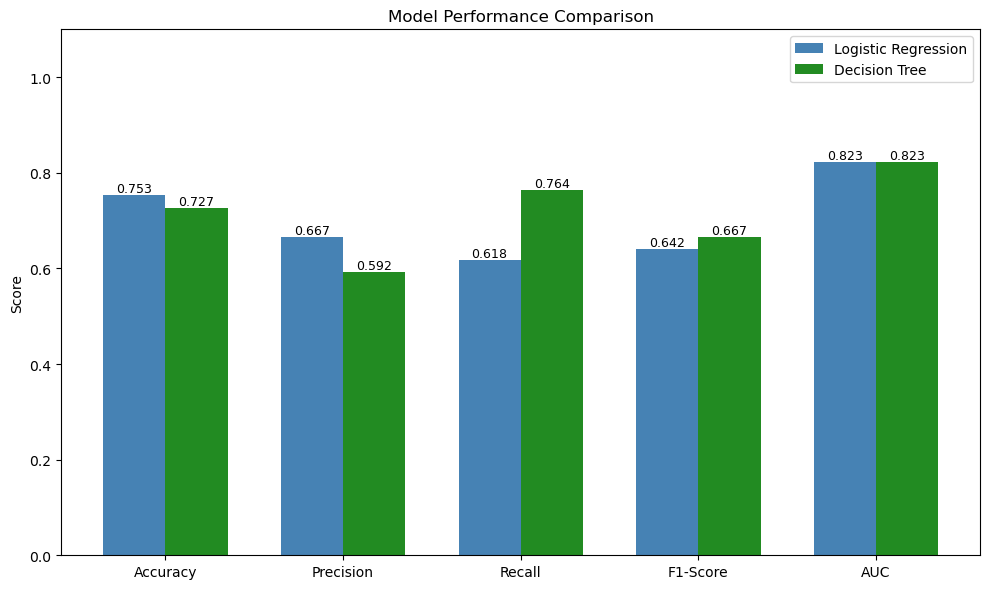

In [40]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
lr_scores = results.iloc[0][metrics].values
dt_scores = results.iloc[1][metrics].values

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree', color='forestgreen')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

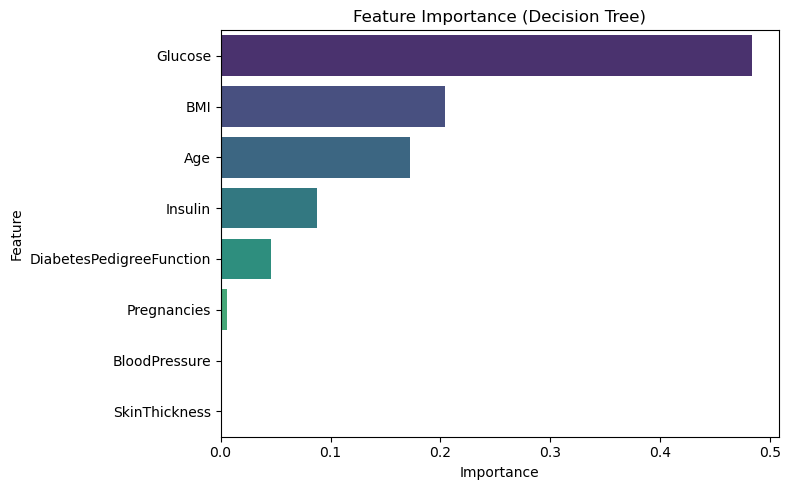

                 Feature  Importance
                 Glucose    0.484042
                     BMI    0.204036
                     Age    0.172308
                 Insulin    0.087886
DiabetesPedigreeFunction    0.045755
             Pregnancies    0.005973
           BloodPressure    0.000000
           SkinThickness    0.000000


In [41]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Decision Tree)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print(importance.to_string(index=False))

### Logistic Regression Hyperparameter Search - Section 5.4

In [42]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_param_grid,
    cv=10,
    scoring='accuracy'
)

lr_grid.fit(X_train_scaled, y_train)

print("Best LR Parameters:")
print(lr_grid.best_params_)
print("Best LR Accuracy:")
print(lr_grid.best_score_)

Best LR Parameters:
{'C': 1}
Best LR Accuracy:
0.7686938127974616


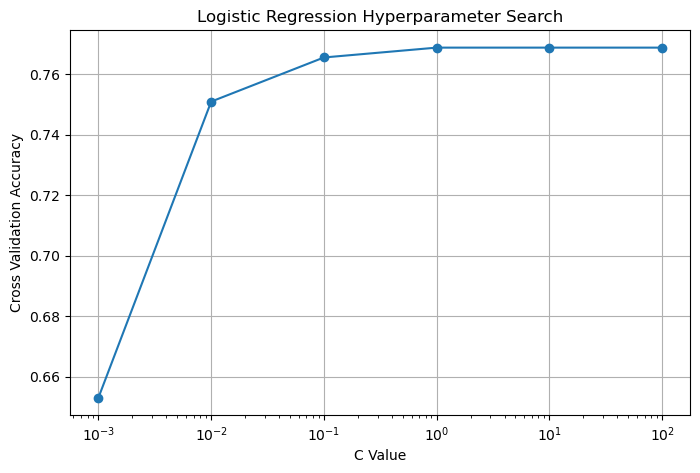

In [43]:
#Plot for LR Optimization
#Figure X. Logistic Regression Hyperparameter Search Using Different C Values
lr_results = pd.DataFrame(lr_grid.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(
    lr_results['param_C'].astype(float),
    lr_results['mean_test_score'],
    marker='o'
)

plt.xscale('log')
plt.xlabel('C Value')
plt.ylabel('Cross Validation Accuracy')
plt.title('Logistic Regression Hyperparameter Search')
plt.grid(True)

plt.savefig('lr_hyperparameter_search.png')
plt.show()

### Decision Tree Hyperparameter Search - Section 5.4

In [44]:
dt_param_grid = {
    'max_depth': [2,3,4,5,6,7,8,10],
    'criterion': ['gini','entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=10,
    scoring='accuracy'
)

dt_grid.fit(X_train, y_train)

print("Best DT Parameters:")
print(dt_grid.best_params_)
print("Best DT Accuracy:")
print(dt_grid.best_score_)

Best DT Parameters:
{'criterion': 'entropy', 'max_depth': 4}
Best DT Accuracy:
0.7621364357482813


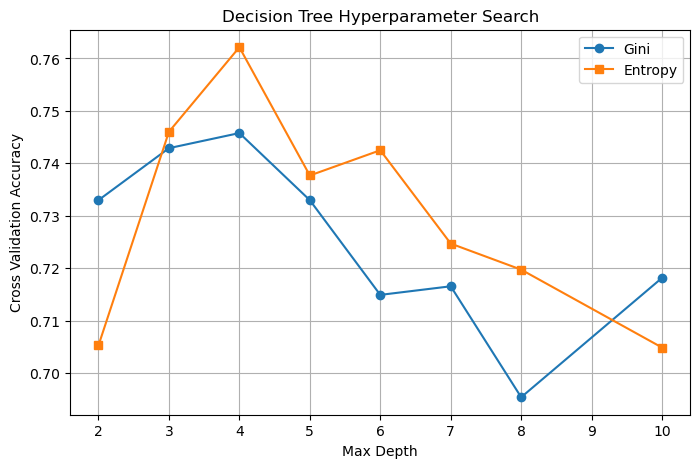

In [45]:
#Plot for DT Optimization
#Figure X. Decision Tree Hyperparameter Search Using Different Tree Depths
dt_results = pd.DataFrame(dt_grid.cv_results_)

gini_results = dt_results[
    dt_results['param_criterion']=='gini'
]

entropy_results = dt_results[
    dt_results['param_criterion']=='entropy'
]

plt.figure(figsize=(8,5))

plt.plot(
    gini_results['param_max_depth'],
    gini_results['mean_test_score'],
    marker='o',
    label='Gini'
)

plt.plot(
    entropy_results['param_max_depth'],
    entropy_results['mean_test_score'],
    marker='s',
    label='Entropy'
)

plt.xlabel('Max Depth')
plt.ylabel('Cross Validation Accuracy')
plt.title('Decision Tree Hyperparameter Search')
plt.legend()
plt.grid(True)

plt.savefig('dt_hyperparameter_search.png')
plt.show()

### Feature Selection Impact Chart - Section 6.1

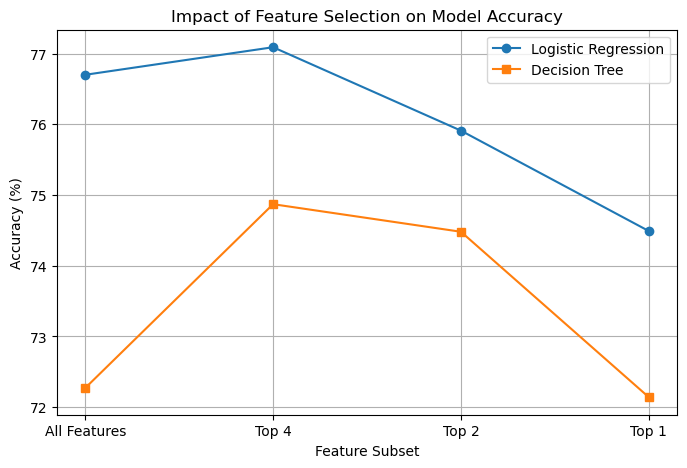

In [46]:
#Figure X. Effect of Feature Selection on Classification Accuracy
feature_sets = [
    'All Features',
    'Top 4',
    'Top 2',
    'Top 1'
]

lr_scores = [76.70, 77.09, 75.91, 74.49]
dt_scores = [72.27, 74.87, 74.48, 72.14]

plt.figure(figsize=(8,5))

plt.plot(feature_sets, lr_scores, marker='o', label='Logistic Regression')

plt.plot(feature_sets, dt_scores, marker='s', label='Decision Tree')

plt.ylabel('Accuracy (%)')
plt.xlabel('Feature Subset')
plt.title('Impact of Feature Selection on Model Accuracy')
plt.legend()
plt.grid(True)

plt.savefig('feature_selection_effect.png')
plt.show()